In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing data:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1718s 10us/step
Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing data: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
    ]
NUM_CLASSES = 10
y_train = y_train.flatten()
y_test = y_test.flatten()

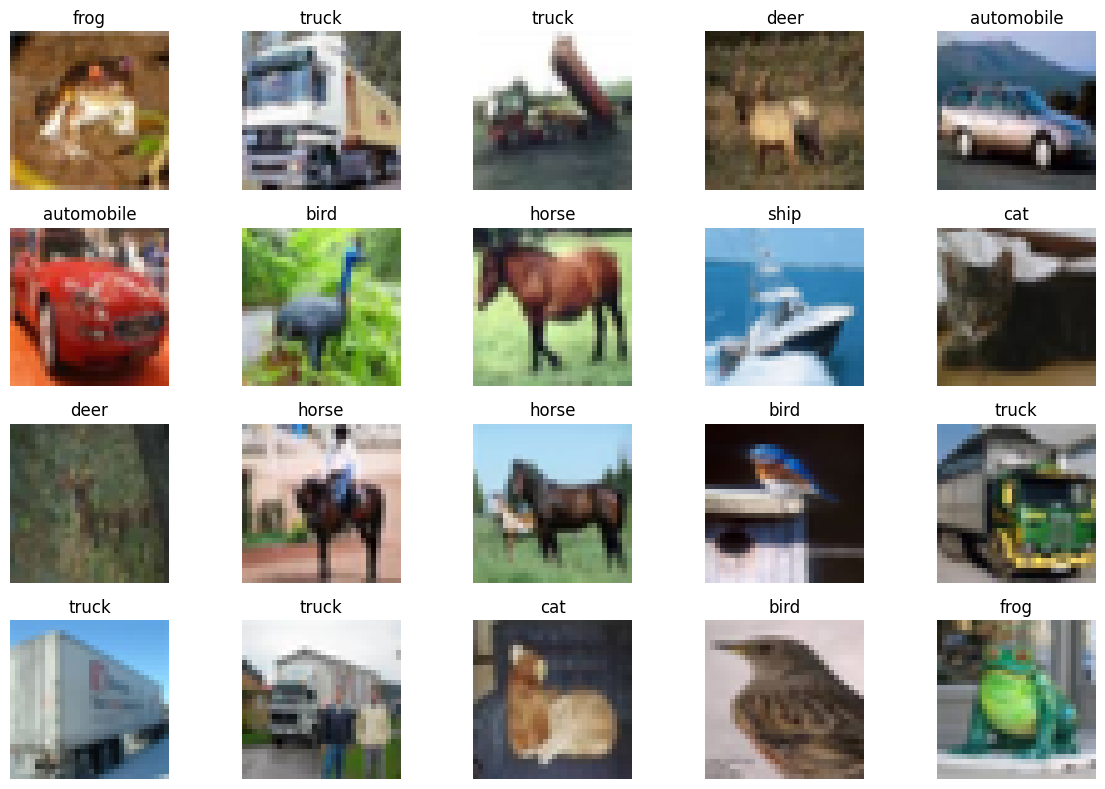

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training:", x_train.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test.shape)


Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64

def create_dataset(images, labels, training=False):

    dataset = tf.data.Dataset.from_tensor_slices(
        (images, labels)
    )

    if training:
        dataset = dataset.shuffle(10000)

    def preprocess(image, label):

        image = tf.cast(image, tf.float32)

        image = tf.image.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        return image, label

    dataset = dataset.map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


In [ ]:
train_ds = create_dataset(
    x_train,
    y_train,
    training=True
)

val_ds = create_dataset(
    x_val,
    y_val
)

test_ds = create_dataset(
    x_test,
    y_test
)

print("Datasets created successfully.")


Datasets created successfully.


In [ ]:
def build_alexnet():

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    x = data_augmentation(inputs)

    x = layers.Rescaling(1./255)(x)

    # Convolution Block 1
    x = layers.Conv2D(
        64,
        kernel_size=11,
        strides=4,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=3,
        strides=2
    )(x)

    # Convolution Block 2
    x = layers.Conv2D(
        128,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=3,
        strides=2
    )(x)

    # Convolution Block 3
    x = layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    # Convolution Block 4
    x = layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    # Convolution Block 5
    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=3,
        strides=2
    )(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="AlexNet"
    )


In [ ]:
alexnet = build_alexnet()

alexnet.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

alexnet.summary()


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 56, 56, 64)     │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,444,106 (5.51 MB)

 Trainable params: 1,444,106 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()

history_alexnet = alexnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

alexnet_time = time.time() - start_time

print(
    "AlexNet training time:",
    round(alexnet_time, 2),
    "seconds"
)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.2438 - loss: 1.9904 - val_accuracy: 0.3812 - val_loss: 1.6880
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3753 - loss: 1.6841 - val_accuracy: 0.4360 - val_loss: 1.5644
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.4370 - loss: 1.5441 - val_accuracy: 0.5132 - val_loss: 1.3437
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.4786 - loss: 1.4387 - val_accuracy: 0.5492 - val_loss: 1.2512
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.5097 - loss: 1.3594 - val_accuracy: 0.5808 - val_loss: 1.1714
AlexNet training time: 184.63 seconds


In [ ]:
alexnet_loss, alexnet_accuracy = alexnet.evaluate(
    test_ds
)

alexnet_error = 1 - alexnet_accuracy

print("AlexNet Test Accuracy:", alexnet_accuracy)
print("AlexNet Error Rate:", alexnet_error)
print(
    f"Accuracy: {alexnet_accuracy * 100:.2f}%"
)

print(
    f"Error Rate: {alexnet_error * 100:.2f}%"
)



157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5741 - loss: 1.1847
AlexNet Test Accuracy: 0.5741000175476074
AlexNet Error Rate: 0.4258999824523926
Accuracy: 57.41%
Error Rate: 42.59%


In [ ]:
def build_vgg16():

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Data augmentation
    x = data_augmentation(inputs)

    # VGG16 preprocessing
    x = preprocess_input(x)

    # Pre-trained VGG16
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze VGG16 layers
    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="VGG16"
    )

In [ ]:
vgg16 = build_vgg16()

vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg16.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
start_time = time.time()

history_vgg16 = vgg16.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)

vgg16_time = time.time() - start_time

print(
    "VGG16 training time:",
    round(vgg16_time, 2),
    "seconds"
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 258s 353ms/step - accuracy: 0.4296 - loss: 1.8748 - val_accuracy: 0.7252 - val_loss: 0.8525
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 369ms/step - accuracy: 0.6168 - loss: 1.1146 - val_accuracy: 0.7692 - val_loss: 0.6806
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 368ms/step - accuracy: 0.6726 - loss: 0.9520 - val_accuracy: 0.7940 - val_loss: 0.6033
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 368ms/step - accuracy: 0.7042 - loss: 0.8650 - val_accuracy: 0.8076 - val_loss: 0.5530
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 276s 392ms/step - accuracy: 0.7236 - loss: 0.8088 - val_accuracy: 0.8174 - val_loss: 0.5243
VGG16 training time: 1312.64 seconds
